In [103]:
## CUSTOMER CHURN ANALYSIS & PREDICTION

In [ ]:
##  Project Objective

# The objective of this project is to analyze customer behavior and predict customer
#churn using machine learning techniques. The project focuses on identifying factors 
# influencing churn such as customer inactivity, account balance, transaction activity, and demographic information".

In [ ]:
## Dataset Description

# The dataset contains customer demographic details, account information, transaction history, and churn status.

# Important columns used:
- age
- gender
- current_balance
- current_month_credit
- current_month_debit
- days_since_last_transaction
- churn

In [ ]:
## Data Cleaning

The following preprocessing steps were performed:
- Checked missing values
- Verified data types
- Removed inconsistencies
- Created age groups for analysis
- Selected numerical columns for correlation analysis

In [ ]:
## Exploratory Data Analysis

Several visualizations were created to identify patterns and customer behavior:
- Churn distribution
- Age group analysis
- Balance comparison
- Transaction activity analysis
- Correlation heatmap

In [ ]:
## Business Insights

- Young customers showed higher churn rates compared to senior customers.
- Customers with lower account balances were more likely to churn.
- Inactive customers demonstrated increased churn behavior.
- Debit transactions were slightly higher than credit transactions, indicating active customer spending patterns.
- Balance-related variables showed strong positive correlation.

In [ ]:
## Machine Learning Model

A Logistic Regression model was developed to predict customer churn using customer activity and transaction-related features.

Features used:
- age
- current_balance
- days_since_last_transaction
- current_month_credit
- current_month_debit

Target variable:
- churn

In [ ]:
## Model Performance

The Logistic Regression model achieved approximately 80% accuracy in predicting customer churn.

This indicates that customer financial behavior and inactivity patterns are useful indicators for identifying churn risk.

In [ ]:
## Conclusion

# "This project successfully analyzed customer behavior and identified important churn-related patterns
#using data analytics and machine learning techniques".

# The findings can help businesses improve customer retention strategies, identify high-risk customers, and make data-driven decisions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
import pandas as pd
df = pd.read_csv("C:/Users/sruth/OneDrive/Desktop/customer_churn/churn_prediction.csv")
df.head()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,days_since_last_transaction,...,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn
0,1,3135,66,0,0,0,187,2,755,224,...,1458.71,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0
1,6,2531,42,0,2,0,1494,3,388,58,...,1401.72,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1
2,7,263,42,1,0,0,1096,2,1666,60,...,16059.34,15211.29,13798.82,0.36,0.36,857.50,286.07,15719.44,15349.75,0
3,8,5922,72,0,0,1,1020,1,1,98,...,7714.19,7859.74,11232.37,0.64,0.64,1299.64,439.26,7076.06,7755.98,0
4,9,1145,46,0,0,0,623,2,317,172,...,8519.53,6511.82,16314.17,0.27,0.27,443.13,5688.44,8563.84,5317.04,0


In [13]:
df.shape

(22067, 21)

In [15]:
df.columns

Index(['customer_id', 'vintage', 'age', 'gender', 'dependents', 'occupation',
       'city', 'customer_nw_category', 'branch_code',
       'days_since_last_transaction', 'current_balance',
       'previous_month_end_balance', 'average_monthly_balance_prevQ',
       'average_monthly_balance_prevQ2', 'current_month_credit',
       'previous_month_credit', 'current_month_debit', 'previous_month_debit',
       'current_month_balance', 'previous_month_balance', 'churn'],
      dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22067 entries, 0 to 22066
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     22067 non-null  int64  
 1   vintage                         22067 non-null  int64  
 2   age                             22067 non-null  int64  
 3   gender                          22067 non-null  int64  
 4   dependents                      22067 non-null  int64  
 5   occupation                      22067 non-null  int64  
 6   city                            22067 non-null  int64  
 7   customer_nw_category            22067 non-null  int64  
 8   branch_code                     22067 non-null  int64  
 9   days_since_last_transaction     22067 non-null  int64  
 10  current_balance                 22067 non-null  float64
 11  previous_month_end_balance      22067 non-null  float64
 12  average_monthly_balance_prevQ   

In [19]:
df.isnull().sum()

customer_id                       0
vintage                           0
age                               0
gender                            0
dependents                        0
occupation                        0
city                              0
customer_nw_category              0
branch_code                       0
days_since_last_transaction       0
current_balance                   0
previous_month_end_balance        0
average_monthly_balance_prevQ     0
average_monthly_balance_prevQ2    0
current_month_credit              0
previous_month_credit             0
current_month_debit               0
previous_month_debit              0
current_month_balance             0
previous_month_balance            0
churn                             0
dtype: int64

In [20]:
df.describe()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,days_since_last_transaction,...,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn
count,22067.000000,22067.000000,22067.000000,22067.000000,22067.000000,22067.000000,22067.000000,22067.000000,22067.000000,22067.000000,...,2.206700e+04,2.206700e+04,22067.000000,2.206700e+04,2.206700e+04,2.206700e+04,2.206700e+04,2.206700e+04,2.206700e+04,22067.000000
mean,15115.161372,2547.069334,47.931345,0.391807,0.377487,0.772420,800.318575,2.211991,874.440975,66.934790,...,7.222013e+03,7.181977e+03,6694.966494,3.943065e+03,3.781366e+03,4.070565e+03,3.720333e+03,7.165418e+03,7.182148e+03,0.193683
std,8737.384035,1598.675520,16.393352,0.488165,1.044629,1.033849,431.454448,0.669556,904.244526,84.133427,...,2.105071e+04,1.927121e+04,17101.802052,8.661750e+04,3.254151e+04,5.726446e+04,2.517514e+04,1.959007e+04,2.097682e+04,0.395192
min,1.000000,180.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,-3.145380e+03,1.428690e+03,-16506.100000,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,-3.374180e+03,-5.171920e+03,0.000000
25%,7522.500000,1321.000000,36.000000,0.000000,0.000000,0.000000,409.000000,2.000000,159.000000,11.000000,...,1.906485e+03,2.209835e+03,1817.980000,3.600000e-01,3.700000e-01,4.700000e-01,4.900000e-01,2.029970e+03,2.090665e+03,0.000000
50%,15120.000000,2202.000000,46.000000,0.000000,0.000000,0.000000,848.000000,2.000000,531.000000,28.000000,...,3.426740e+03,3.592880e+03,3380.690000,1.130000e+00,6.440000e+00,2.147300e+02,2.285000e+02,3.501740e+03,3.508160e+03,0.000000
75%,22685.500000,3370.000000,60.000000,1.000000,0.000000,2.000000,1096.000000,3.000000,1374.000000,90.000000,...,6.826095e+03,6.819235e+03,6628.750000,9.937800e+02,1.129115e+03,1.579220e+03,1.643175e+03,6.858385e+03,6.779355e+03,0.000000
max,30301.000000,11353.000000,90.000000,1.000000,52.000000,4.000000,1649.000000,3.000000,4782.000000,365.000000,...,1.001124e+06,1.192704e+06,856596.510000,1.226985e+07,2.361808e+06,7.637857e+06,1.414168e+06,1.074625e+06,1.326487e+06,1.000000


In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df['age'].describe()

count    22067.000000
mean        47.931345
std         16.393352
min          1.000000
25%         36.000000
50%         46.000000
75%         60.000000
max         90.000000
Name: age, dtype: float64

In [23]:
df['current_month_balance'].mean()

np.float64(7165.417796256854)

In [24]:
df['current_month_balance'].max()

1074624.64

In [25]:
df['current_month_balance'].min()

-3374.18

In [26]:
df['customer_nw_category'].value_counts()

customer_nw_category
2    11183
3     7781
1     3103
Name: count, dtype: int64

In [6]:
import pandas as pd
df['churn'].value_counts()

churn
0    17793
1     4274
Name: count, dtype: int64

In [9]:
df.groupby("churn")['age'].mean()

churn
0    48.173327
1    46.923959
Name: age, dtype: float64

In [12]:
df.groupby("churn")['current_month_balance'].mean()

churn
0    7271.478358
1    6723.879291
Name: current_month_balance, dtype: float64

In [13]:
df.groupby("churn")['days_since_last_transaction'].mean()

churn
0    69.262856
1    57.242864
Name: days_since_last_transaction, dtype: float64

In [14]:
df.groupby("churn")['customer_nw_category'].mean()

churn
0    2.208959
1    2.224614
Name: customer_nw_category, dtype: float64

In [19]:
df.groupby("occupation")['churn'].mean()

occupation
0    0.206417
1    0.160562
2    0.177080
3    0.177502
4    0.125000
Name: churn, dtype: float64

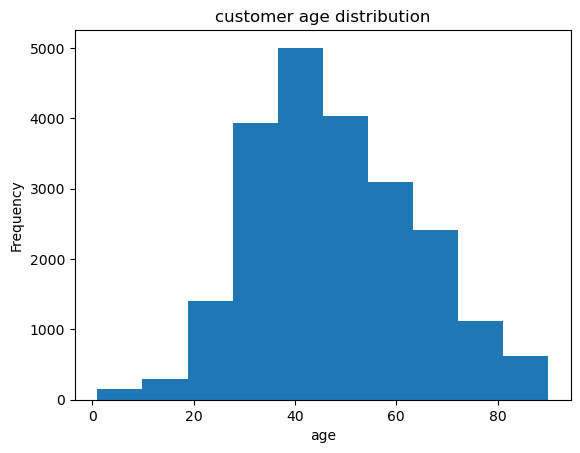

In [34]:
df['age'].plot(kind='hist').bins=10
plt.title("customer age distribution")
plt.xlabel("age")
plt.show()

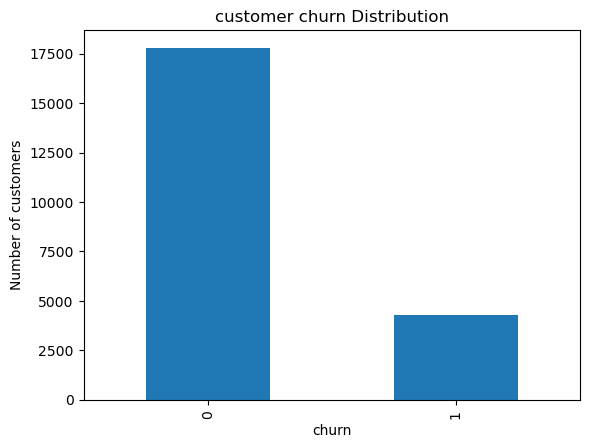

In [111]:
df['churn'].value_counts().plot(kind='bar')
plt.title("customer churn Distribution")
plt.xlabel("churn")
plt.ylabel("Number of customers")
plt.savefig("customer churn Distribution.png")
plt.show()

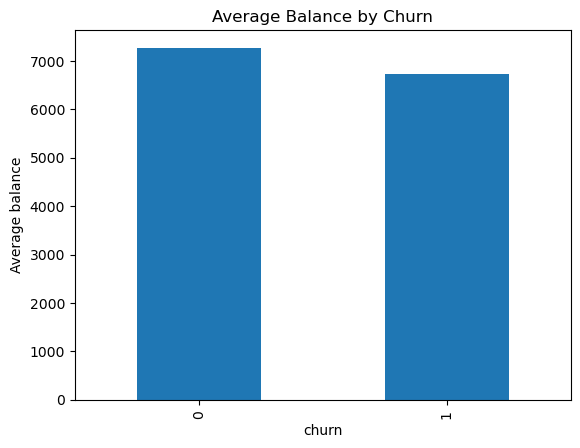

In [70]:
df.groupby('churn')['current_month_balance'].mean().plot(kind='bar')
plt.title("Average Balance by Churn")
plt.ylabel("Average balance")
plt.savefig("Average Balance by Churn.png")
plt.show()

In [ ]:
# Insight:
# Low balance customers are more likely to churn
# may feel less connected to bank
# may switch banks more easily
# RECOMMENDATION:
# Bank can offer loyalty rewards
# Provide personalized offers for low_balance customers.

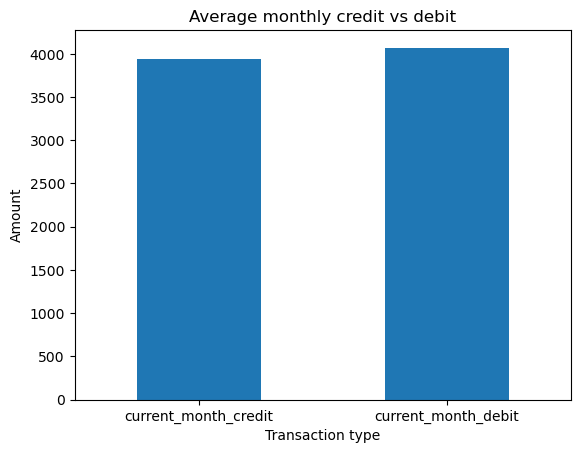

In [71]:
df[['current_month_credit','current_month_debit']].mean().plot(kind='bar')
plt.title("Average monthly credit vs debit")
plt.xlabel("Transaction type")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.savefig("Average monthly credit vs debit.png")
plt.show()

In [ ]:
# Insight:
# Customers both credit and debit values are high 
# Customers are actively using banking services
# "Average debit transactions are slightly higher than the credit transactions , indicating 
# customers using the bank service more for spending activities".

In [78]:
import seaborn as sns



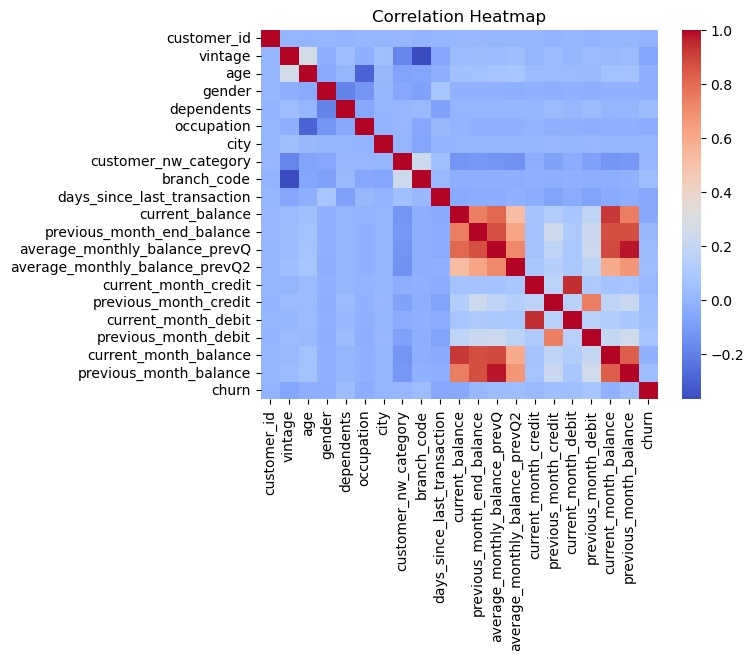

In [81]:
numeric_df=df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(),cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("heatmap.png")
plt.show()

In [ ]:
# Insight:
# " The correlation heatmap revealed strong positive relationships amomg balance-related
# and transaction-related varaibles, indicating consistent customer financial behaviour patterns.
# Most variables showed weak correlations, suggestions churnn behaviour is influenced
# by multiple combined factors rather than a single feature."

In [50]:
churn_rate=df['churn'].value_counts(normalize=True)*100
print(churn_rate)

churn
0    80.631713
1    19.368287
Name: proportion, dtype: float64


In [52]:
df.groupby('churn')
    [['current_month_balance','days_since_last_transaction','current_month_credit']].mean()

,current_month_balance,days_since_last_transaction,current_month_credit
churn,,,
0,7271.478358,69.262856,2996.164510
1,6723.879291,57.242864,7885.085384


In [58]:
df['age_group']=pd.cut(
    df['age'],bins=[18,30,45,60,100],
    labels=["young","Adult","Middle age","senior"])

In [60]:
df['age_group'].value_counts()

age_group
Adult         7867
Middle age    6061
senior        5208
young         2475
Name: count, dtype: int64

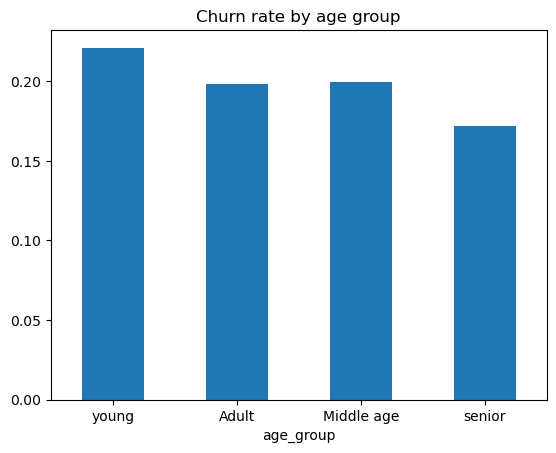

In [82]:
df.groupby('age_group',observed=False)['churn'].mean().plot(kind='bar')
plt.title("Churn rate by age group")
plt.xticks(rotation=0)
plt.savefig("Churn rate by age group")
plt.show()

In [83]:
# Business Insights

In [84]:
# Insights:
# Young customers have the highest churn rate.
# Senior customers shows stronger retention.
# RECOMMENDATION:
# Create engagement offers for younger customers.

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [89]:
x= df[['age',
       'current_month_balance',
       'days_since_last_transaction',
       'current_month_credit',
       'current_month_debit']]
y= df['churn']

In [91]:
x_train,x_test,y_train,y_test= train_test_split(
    x,y,
    test_size= 0.2,
    random_state= 42
)

In [100]:
model=LogisticRegression(max_iter=1000)

In [101]:
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [98]:
y_pred= model.predict(x_test)

In [102]:
accuracy= accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.8017671046669688


In [104]:
# “A Logistic Regression model was developed to predict customer churn using customer demographic 
# and transactional features. The model achieved approximately 80% prediction accuracy, demonstrating 
# the effectiveness of customer activity and financial behavior in identifying churn risk.”

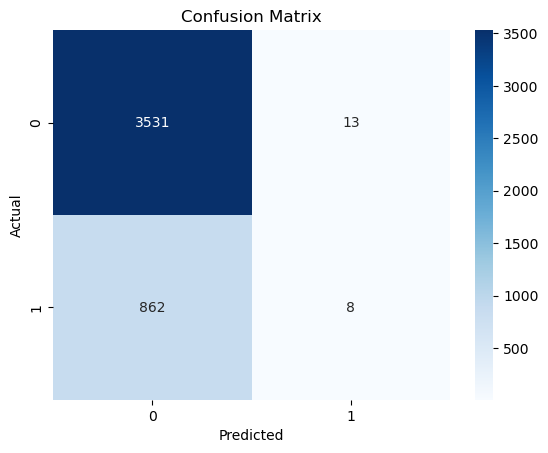

In [106]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [108]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      3544
           1       0.38      0.01      0.02       870

    accuracy                           0.80      4414
   macro avg       0.59      0.50      0.45      4414
weighted avg       0.72      0.80      0.72      4414



In [110]:
## PROJECT INSIGHTS
# Customer with low balance showed higher churn tendency.
# Young customers had slightly higher churn rates.
# Debit transactions were slightly higher than credit transactions.
# Balance-related features showed strong correlation.
# Logistic Regression model achived nearly 80% accuracy in predicting churn.

In [ ]:
### BUSINESS RECOMMENDATIONS
# Bank should target low balance customers with retention offers.
# personalized engagement can reduce churn among younger customers
# Monitoring transactions behavior may help identify risky customers early.